# Variable Tracking

Запуск эксперимента `variables_tracking/` в стиле `graph_connectivity/`.


## 0. Setup


In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
personal_token = user_secrets.get_secret("GITHUB_TOKEN")

# !rm -rf transformer-analyzing
# !git clone https://{personal_token}@github.com/maximvw/transformer-analyzing.git transformer-analyzing
%cd transformer-analyzing

/kaggle/working/transformer-analyzing


In [2]:
import os
import sys
from pathlib import Path

import torch

print("Python:", sys.executable)
PYTHON = sys.executable
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} | {props.total_memory / 1e9:.1f} GB")

ROOT = Path.cwd()
DATA_DIR = ROOT / "variables_tracking" / "data"
CKPT_DIR = ROOT / "checkpoints"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)


Python: /usr/bin/python3
CUDA available: True
CUDA devices: 2
GPU 0: Tesla T4 | 15.6 GB
GPU 1: Tesla T4 | 15.6 GB


## 0. Конфиг


In [3]:
MIN_LEN = 1
MAX_LEN = 20
OOD_MIN_LEN = 24
OOD_MAX_LEN = 40
MAX_VALUE = 32

N_TRAIN = 80000
N_VAL = 1000
N_TEST = 1000

D_MODEL = 128
N_HEAD = 4
BATCH_SIZE = 128
EPOCHS = 100
PATIENCE = 25
LR = 1e-4
AUX_LAMBDA = 20.0


## 1. Генерация данных

In [4]:
!$PYTHON -m variables_tracking.scripts.generate_data \
    --output_dir "$DATA_DIR" \
    --n_train $N_TRAIN \
    --n_val $N_VAL \
    --n_test $N_TEST \
    --min_len $MIN_LEN \
    --max_len $MAX_LEN \
    --ood_min_len $OOD_MIN_LEN \
    --ood_max_len $OOD_MAX_LEN \
    --max_value $MAX_VALUE \
    --seed 42


train: n=80000 | len=[1, 20] | avg_len=10.47 | avg_depth=2.11 | types={'random': 80000}
val: n=1000 | len=[1, 20] | avg_len=10.30 | avg_depth=2.10 | types={'random': 1000}
test_id: n=1000 | len=[1, 20] | avg_len=10.46 | avg_depth=2.18 | types={'random': 1000}
test_ood_long: n=1000 | len=[24, 40] | avg_len=31.87 | avg_depth=4.54 | types={'random': 1000}
test_ood_chain: n=1000 | len=[24, 40] | avg_len=31.77 | avg_depth=31.77 | types={'chain': 1000}
test_ood_distractor: n=1000 | len=[24, 40] | avg_len=31.85 | avg_depth=10.30 | types={'distractor': 1000}


In [5]:
import json

for path in sorted(DATA_DIR.glob("*.json")):
    with open(path) as f:
        items = json.load(f)
    print(f"{path.name}: {len(items)} examples")
    if items:
        ex = items[0]
        print("  sample length:", ex["length"], "query:", ex["query_var"], "answer:", ex["answer"], "type:", ex["program_type"])
        print("  sample program:", " ".join(ex["program"][:6]))


test_id.json: 1000 examples
  sample length: 14 query: w answer: 0 type: random
  sample program: DEC(x) SET(y,18) SET(x,0) SET(z,24) DEC(z) COPY(z,z)
test_ood_chain.json: 1000 examples
  sample length: 26 query: y answer: 21 type: chain
  sample program: SET(w,2) ADDC(y,w,9) COPY(x,y) ADDC(z,x,3) COPY(x,z) ADDC(z,x,5)
test_ood_distractor.json: 1000 examples
  sample length: 35 query: x answer: 13 type: distractor
  sample program: SET(x,27) INC(x) INC(x) ADDC(x,x,24) ADDC(x,x,2) INC(x)
test_ood_long.json: 1000 examples
  sample length: 32 query: z answer: 11 type: random
  sample program: INC(z) SET(z,1) SET(x,7) COPY(x,z) ADDC(x,x,8) COPY(y,y)
train.json: 80000 examples
  sample length: 4 query: x answer: 31 type: random
  sample program: SET(z,15) COPY(x,x) DEC(x) SET(y,14)
val.json: 1000 examples
  sample length: 2 query: w answer: 0 type: random
  sample program: COPY(y,w) COPY(x,w)


## 2. Обучение SFT baseline


In [6]:
# for n_layer in [2, 4, 6]:
for n_layer in [6]:

    print(f"\n{'=' * 70}")
    print(f"Training Variable Tracking SFT {n_layer}L")
    print(f"{'=' * 70}")
    SAVE_DIR = CKPT_DIR / f"variables_sft_{n_layer}L"
    !"$PYTHON" -m variables_tracking.src.train \
        --train_path "{DATA_DIR / 'train.json'}" \
        --val_path "{DATA_DIR / 'val.json'}" \
        --max_value {MAX_VALUE} \
        --d_model {D_MODEL} --n_layer {n_layer} --n_head {N_HEAD} \
        --max_seq_len 64 \
        --lr {LR} --weight_decay 0.01 \
        --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
        --lambda_state 0.0 \
        --num_workers 2 \
        --save_dir "{SAVE_DIR}" \
        --seed 42



Training Variable Tracking SFT 6L
Device: cuda
Vocab size: 769
Model parameters: 1,300,640
Using 2 GPUs with DataParallel
Epoch   0 | train loss=2.8537 acc=0.2799 | val loss=2.7417 acc=0.2950           
Epoch   1 | train loss=2.7630 acc=0.2811 | val loss=2.6673 acc=0.3000           
Epoch   2 | train loss=2.6021 acc=0.3210 | val loss=2.4521 acc=0.3940           
Epoch   3 | train loss=2.2654 acc=0.4540 | val loss=2.1178 acc=0.4980           
Epoch   4 | train loss=1.9902 acc=0.5181 | val loss=1.9338 acc=0.5320           
Epoch   5 | train loss=1.8141 acc=0.5422 | val loss=1.8066 acc=0.5560           
Epoch   6 | train loss=1.6755 acc=0.5656 | val loss=1.7132 acc=0.5690           
Epoch   7 | train loss=1.5446 acc=0.5920 | val loss=1.5993 acc=0.5810           
Epoch   8 | train loss=1.4463 acc=0.6149 | val loss=1.5293 acc=0.5980           
Epoch   9 | train loss=1.3787 acc=0.6318 | val loss=1.5129 acc=0.6070           
Epoch  10 | train loss=1.3242 acc=0.6444 | val loss=1.4738 acc=0.62

## 3. Обучение 2L + Auxiliary Loss


In [7]:
# SAVE_DIR = CKPT_DIR / "variables_aux_2L"

# !"$PYTHON" -m variables_tracking.src.train \
#     --train_path "{DATA_DIR / 'train.json'}" \
#     --val_path "{DATA_DIR / 'val.json'}" \
#     --max_value {MAX_VALUE} \
#     --d_model {D_MODEL} --n_layer 2 --n_head {N_HEAD} \
#     --max_seq_len 64 \
#     --lr {LR} --weight_decay 0.01 \
#     --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
#     --lambda_state {AUX_LAMBDA} \
#     --num_workers 2 \
#     --save_dir "{SAVE_DIR}" \
#     --seed 42


## 4. Evaluation


In [8]:
from variables_tracking.src.evaluate import evaluate_all

all_eval = {}
variables = ["x", "y", "z", "w"]

for n_layer in [2, 4, 6]:
    name = f"SFT {n_layer}L"
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")
    all_eval[name] = evaluate_all(
        checkpoint_path=str(CKPT_DIR / f"variables_sft_{n_layer}L" / "checkpoint_best.pt"),
        data_dir=str(DATA_DIR),
        variables=variables,
        max_value=MAX_VALUE,
        batch_size=BATCH_SIZE,
        lambda_state=0.0,
        d_model=D_MODEL,
        n_layer=n_layer,
        n_head=N_HEAD,
        max_seq_len=64,
    )

print(f"\n{'=' * 70}")
print("2L + Aux")
print(f"{'=' * 70}")
all_eval["2L + Aux"] = evaluate_all(
    checkpoint_path=str(CKPT_DIR / "variables_aux_2L" / "checkpoint_best.pt"),
    data_dir=str(DATA_DIR),
    variables=variables,
    max_value=MAX_VALUE,
    batch_size=BATCH_SIZE,
    lambda_state=AUX_LAMBDA,
    d_model=D_MODEL,
    n_layer=2,
    n_head=N_HEAD,
    max_seq_len=64,
)



SFT 2L
test_id: accuracy=0.6170 loss=1.5007 (n=1000)
test_ood_chain: accuracy=0.0260 loss=3.7866 (n=1000)
test_ood_distractor: accuracy=0.0200 loss=4.0291 (n=1000)
test_ood_long: accuracy=0.0700 loss=4.3829 (n=1000)

SFT 4L
test_id: accuracy=0.6390 loss=1.3946 (n=1000)
test_ood_chain: accuracy=0.0260 loss=3.6347 (n=1000)
test_ood_distractor: accuracy=0.0250 loss=4.0626 (n=1000)
test_ood_long: accuracy=0.0700 loss=4.2289 (n=1000)

SFT 6L
test_id: accuracy=0.6470 loss=1.3757 (n=1000)
test_ood_chain: accuracy=0.0250 loss=3.6062 (n=1000)
test_ood_distractor: accuracy=0.0310 loss=4.3054 (n=1000)
test_ood_long: accuracy=0.0820 loss=4.4548 (n=1000)

2L + Aux
test_id: accuracy=0.7120 loss=16.0162 (n=1000)
test_ood_chain: accuracy=0.0360 loss=91.5173 (n=1000)
test_ood_distractor: accuracy=0.0200 loss=77.0885 (n=1000)
test_ood_long: accuracy=0.0800 loss=62.1684 (n=1000)


In [9]:
import pandas as pd

rows = []
for name, results in all_eval.items():
    row = {"Model": name}
    for split_name, metrics in results.items():
        row[split_name] = f"{metrics['accuracy']:.1%}"
    rows.append(row)
df = pd.DataFrame(rows)
df


,Model,test_id,test_ood_chain,test_ood_distractor,test_ood_long
0,SFT 2L,61.7%,2.6%,2.0%,7.0%
1,SFT 4L,63.9%,2.6%,2.5%,7.0%
2,SFT 6L,64.7%,2.5%,3.1%,8.2%
3,2L + Aux,71.2%,3.6%,2.0%,8.0%


## 5. Training Curves


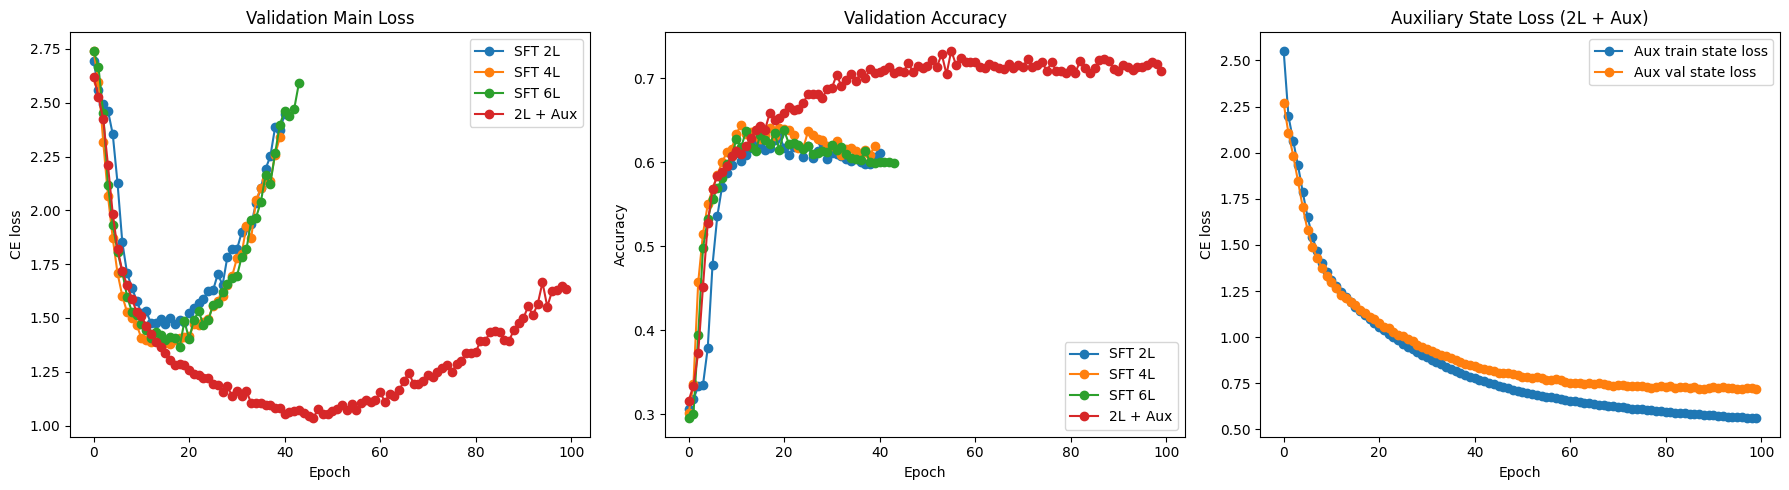

In [10]:
import matplotlib.pyplot as plt

def load_log(path):
    with open(path) as f:
        return json.load(f)

logs = {
    "SFT 2L": load_log(CKPT_DIR / "variables_sft_2L" / "train_log.json"),
    "SFT 4L": load_log(CKPT_DIR / "variables_sft_4L" / "train_log.json"),
    "SFT 6L": load_log(CKPT_DIR / "variables_sft_6L" / "train_log.json"),
    "2L + Aux": load_log(CKPT_DIR / "variables_aux_2L" / "train_log.json"),
}

# В этом эксперименте loss_main = основной answer-prediction loss.
# Это честный аналог NTP-части objective, который можно сравнивать между SFT и Aux.
# loss_state рисуем отдельно, потому что он живёт в другом масштабе.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, log in logs.items():
    epochs = [row["epoch"] for row in log]
    val_acc = [row["val"]["accuracy"] for row in log]
    val_main = [row["val"]["loss_main"] for row in log]
    axes[0].plot(epochs, val_main, marker="o", label=label)
    axes[1].plot(epochs, val_acc, marker="o", label=label)

aux_log = logs["2L + Aux"]
aux_epochs = [row["epoch"] for row in aux_log]
aux_train_state = [row["train"]["loss_state"] for row in aux_log]
aux_val_state = [row["val"]["loss_state"] for row in aux_log]
axes[2].plot(aux_epochs, aux_train_state, marker="o", label="Aux train state loss")
axes[2].plot(aux_epochs, aux_val_state, marker="o", label="Aux val state loss")

axes[0].set_title("Validation Main Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CE loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].set_title("Auxiliary State Loss (2L + Aux)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("CE loss")
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. OOD Comparison


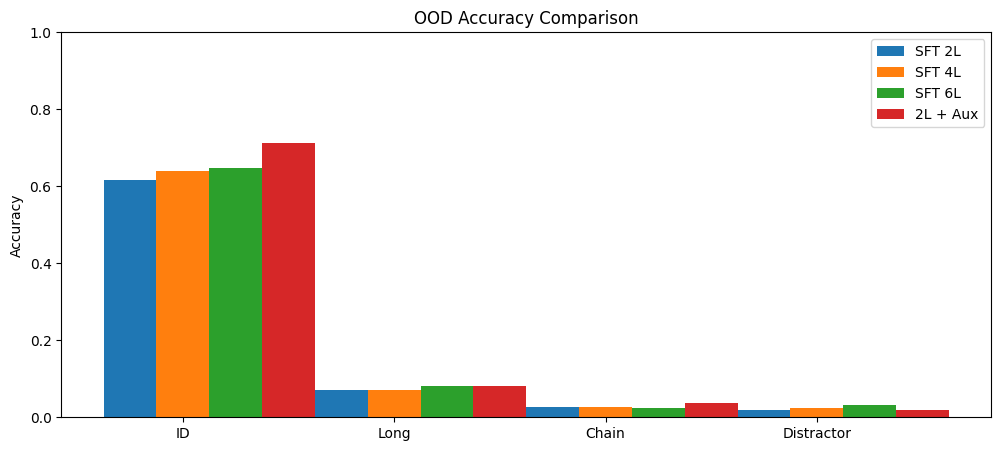

In [11]:
import numpy as np

splits = ["test_id", "test_ood_long", "test_ood_chain", "test_ood_distractor"]
labels = ["ID", "Long", "Chain", "Distractor"]
model_names = list(all_eval.keys())

x = np.arange(len(splits))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for idx, model_name in enumerate(model_names):
    values = [all_eval[model_name][split]["accuracy"] for split in splits]
    ax.bar(x + idx * width - width, values, width=width, label=model_name)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("OOD Accuracy Comparison")
ax.legend()
plt.show()


## 7. Accuracy by Program Length


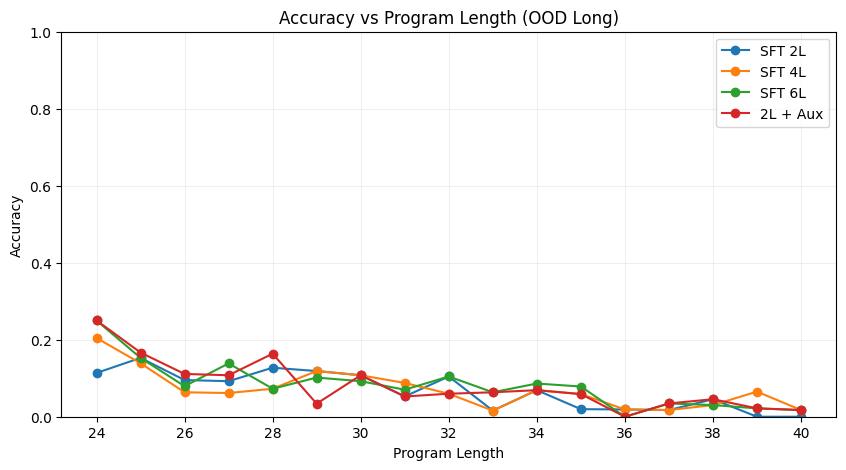

In [12]:
from collections import defaultdict
from torch.utils.data import DataLoader

from variables_tracking.src.data import VariableTrackingDataset, collate_fn
from variables_tracking.src.evaluate import load_checkpoint
from variables_tracking.src.tokenizer import VariableTrackingTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = VariableTrackingTokenizer(variables=variables, max_value=MAX_VALUE)
test_ds = VariableTrackingDataset(DATA_DIR / "test_ood_long.json", tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

def load_model_bundle(ckpt_path, n_layer, lambda_state):
    model, probe = load_checkpoint(
        checkpoint_path=ckpt_path,
        tokenizer=tokenizer,
        device=device,
        max_value=MAX_VALUE,
        d_model=D_MODEL,
        n_layer=n_layer,
        n_head=N_HEAD,
        max_seq_len=64,
    )
    model.eval()
    if probe is not None:
        probe.eval()
    return model, probe, lambda_state

bundles = {
    "SFT 2L": load_model_bundle(CKPT_DIR / "variables_sft_2L" / "checkpoint_best.pt", 2, 0.0),
    "SFT 4L": load_model_bundle(CKPT_DIR / "variables_sft_4L" / "checkpoint_best.pt", 4, 0.0),
    "SFT 6L": load_model_bundle(CKPT_DIR / "variables_sft_6L" / "checkpoint_best.pt", 6, 0.0),
    "2L + Aux": load_model_bundle(CKPT_DIR / "variables_aux_2L" / "checkpoint_best.pt", 2, AUX_LAMBDA),
}

@torch.no_grad()
def accuracy_by_length(model):
    buckets = defaultdict(lambda: [0, 0])
    for batch in test_loader:
        ids = batch["input_ids"].to(device)
        ans_pos = batch["ans_pos"].to(device)
        hidden, _ = model(ids, ids != 0)
        logits = model.classifier(hidden[torch.arange(ids.size(0), device=device), ans_pos])
        preds = logits.argmax(dim=-1).cpu()
        for i in range(ids.size(0)):
            length = batch["program_length"][i].item()
            ok = int(preds[i].item() == batch["targets"][i].item())
            buckets[length][0] += ok
            buckets[length][1] += 1
    xs = sorted(buckets)
    ys = [buckets[x][0] / buckets[x][1] for x in xs]
    return xs, ys

plt.figure(figsize=(10, 5))
for label, (model, probe, lam) in bundles.items():
    xs, ys = accuracy_by_length(model)
    plt.plot(xs, ys, marker="o", label=label)
plt.xlabel("Program Length")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.title("Accuracy vs Program Length (OOD Long)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
